In [1]:
%load_ext autoreload
%autoreload 0
%matplotlib inline

In [2]:
import re,sys,os
import pandas as pd
import numpy as np
from tqdm import tqdm
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib

# Set font to Arial
matplotlib.rcParams['font.family'] = 'Arial'

# Optional: Set PDF to embed fonts (for Illustrator editing)
matplotlib.rcParams['pdf.fonttype'] = 42  # TrueType fonts for better editing

In [3]:
DATA_DIR = Path(r"E:\lab\cptac-prostate\runs\20260401_quality_control")
OUTPUT_DIR = Path(r"E:\lab\cptac-prostate\runs\20260401_mspycloud_cptac_protein_tmt_pca")
OUTPUT_DIR.mkdir(exist_ok=True)
print(DATA_DIR.exists(), OUTPUT_DIR.exists())
meta_path = DATA_DIR / "20_MetaData_03_12_2026_renamed.csv"

True True


In [4]:
meta = pd.read_csv(meta_path)
meta

,case_id,common_ID,Tissuetype,include_or_excludetumor,FirstCategory,AdditionalSegments,SecondCategory,ThirdCategory,all_drivers,Main_Groups,...,Normal_Pam50,Basal,Her2,LumA,LumB,Normal,agg_rank_raw,agg_rank_scaled,risk_group,SampleID
0,C3L-07287,C3L.07287.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.000000,0.0,0.0,1.0,0.0,0.0,55.333000,0.409000,IR,C3L-07287_T
1,C3L-11156,C3L.11156.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.498000,0.0,0.0,1.0,0.0,0.0,44.167000,0.325000,LR,C3L-11156_T
2,C3L-09494,C3L.09494.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.000000,0.0,1.0,0.0,0.0,0.0,123.167000,0.919000,HR,C3L-09494_T
3,CHTN-49141,CHTN.49141.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.000000,0.0,1.0,0.0,0.0,0.0,103.833000,0.773000,HR,CHTN-49141_T
4,C3L-11095,C3L.11095.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.369000,0.0,0.0,1.0,0.0,0.0,44.667000,0.328000,LR,C3L-11095_T
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,C3L-07872,C3L.07872.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.460832,1.0,0.0,0.0,0.0,0.0,73.666667,0.546366,IR,C3L-07872_T
179,C3L-08642,C3L.08642.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.334840,0.0,0.0,1.0,0.0,0.0,46.166667,0.339599,LR,C3L-08642_T
180,C3L-10399,C3L.10399.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.445334,0.0,0.0,1.0,0.0,0.0,60.000000,0.443609,IR,C3L-10399_T
181,C3L-05301,C3L.05301.T,tumor,Include,Low Purity,NaN,NaN,NaN,ETV1,ETV1,...,0.457908,0.0,0.0,1.0,0.0,0.0,45.333333,0.333333,LR,C3L-05301_T


In [5]:
meta_normal = meta[meta["Tissuetype"] == "normal"]

In [6]:
purity_map = dict(zip(meta["SampleID"], meta["FirstCategory"]))
stage_map = dict(zip(meta["SampleID"], meta["stage"]))
gleason_map = dict(zip(meta["SampleID"], meta["Grade_Group"]))

In [7]:
meta_tumor = meta[meta["Tissuetype"] == "tumor"]

In [8]:
tumors_included = meta_tumor['SampleID'].tolist()
print(len(tumors_included))

150


In [9]:
normals = meta_normal['SampleID'].tolist()
print(len(normals))

33


In [10]:
tumors_included, normals

(['C3L-07287_T',
  'C3L-11156_T',
  'C3L-09494_T',
  'CHTN-49141_T',
  'C3L-11095_T',
  'C3L-06504_T',
  'C3L-07473_T',
  'C3L-08293_T',
  'C3L-09382_T',
  'C3L-09691_T',
  'C3L-09757_T',
  'C3L-09801_T',
  'C3L-09990_T',
  'C3N-08476_T',
  'C3N-08532_T',
  'C3N-08879_T',
  'C3N-08880_T',
  'C3N-08949_T',
  'C3N-08878_T',
  'C3L-10486_T',
  'C3L-06183_T',
  'C3L-09383_T',
  'C3L-06743_T',
  'C3L-07871_T',
  'C3L-08290_T',
  'C3L-09797_T',
  'C3L-10005_T',
  'C3N-08477_T',
  'C3L-06662_T',
  'C3L-07877_T',
  'C3L-06901_T',
  'C3L-08444_T',
  'C3L-08942_T',
  'C3L-07875_T',
  'C3L-06656_T',
  'C3L-07606_T',
  'C3L-08286_T',
  'C3L-08288_T',
  'C3L-08330_T',
  'C3L-08941_T',
  'C3L-09107_T',
  'C3L-09759_T',
  'C3L-08243_T',
  'C3N-08535_T',
  'C3L-08933_T',
  'C3L-07804_T',
  'C3L-08814_T',
  'C3L-05670_T',
  'C3L-08811_T',
  'C3L-06595_T',
  'C3L-06969_T',
  'CHTN-40852_T',
  'C3N-08950_T',
  'C3N-08906_T',
  'C3L-09696_T',
  'C3L-10308_T',
  'C3L-06506_T',
  'C3L-09375_T',
  'C3N-08952

In [11]:
# data
files = [i for i in DATA_DIR.iterdir() if i.is_file()]
files = [i for i in files if re.search(r"site_matrix-log2_ratios-MD_norm",i.stem, re.IGNORECASE) \
    and not re.search(r"tumor_purity_corrected",i.stem, re.IGNORECASE)]
data_path = files[0]

print(data_path, data_path.exists())

E:\lab\cptac-prostate\runs\20260401_quality_control\site_matrix-log2_ratios-MD_norm.tsv True


In [12]:
pd.read_csv(data_path,sep="\t")

,Modifications,Reference Sample 1,Sample 1,Sample 2,Sample 3,Sample 4,Sample 5,Sample 6,Sample 7,Sample 8,...,Sample 195,Sample 196,Sample 197,Sample 198,Sample 199,Sample 200,Sample 201,Sample 202,Sample 203,Sample 204
0,[304.207146]AAAAAAALQAK[114.042927]SDEK[304.20...,0.0,-0.827655,-0.742708,-0.556025,-0.194037,-0.232627,0.221023,-0.946875,-0.722395,...,0.333053,0.721572,0.821910,0.783937,0.141135,0.019784,-0.056945,0.979122,1.044169,1.730977
1,[304.207146]AAAASAAEAGIATTGTEDSDDALLK[114.0429...,0.0,-0.090885,-0.051857,-0.075564,-0.750425,-0.249648,0.096765,-0.317282,-2.190656,...,1.727200,2.099415,-0.868990,1.714846,1.321708,1.415628,2.039759,1.665831,1.193453,1.601708
2,[304.207146]AAAASAAEAGIATTGTEDSDDALLK[114.0429...,0.0,0.368371,0.406840,-0.311166,0.242944,0.478435,1.223583,-0.068302,-0.763611,...,0.361530,0.274437,-0.549142,0.393883,-1.998589,-1.519461,1.042343,-0.141309,-0.100334,-0.247398
3,[304.207146]AAAEAAAEAK[114.042927]AR,0.0,-0.325326,0.340476,-1.012782,-0.170096,-0.491666,-0.505240,-0.230172,0.438315,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,[304.207146]AAAFEEQENETVVVK[114.042927]EK[304....,0.0,-0.771500,-0.092843,0.155859,0.444185,-0.005953,0.062806,0.345561,0.287744,...,-0.160462,1.117618,0.904013,-0.509897,0.540633,-0.747804,0.991785,0.772774,0.323188,-0.413089
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22221,[304.207146]YQSNSIQIQWFWR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.223130,-0.194829,-0.798569,0.126824,-2.299942,-1.061893,-0.131664,-0.156097,-0.401172,-0.688381
22222,[304.207146]YSTAK[114.042927]NANFYLQAGSAFAEMK[...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.326152,0.154745,0.062193,1.055814,-1.154543,1.709054,0.866790,-0.148985,0.022976,1.688861
22223,[304.207146]YTIIIPENLK[114.042927]PQMK[304.207...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.502253,-1.060129,0.026345,-0.126991,-0.694871,-0.047683,-0.028053,-1.380989,-0.169681,-0.051871
22224,[304.207146]YWETK[114.042927]QAFIK[304.207146],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.078772,0.053054,0.089244,-0.048069,-1.197591,-0.162948,0.402337,0.144350,0.177532,-0.146298


In [13]:
data = pd.read_csv(data_path,sep="\t")
data

,Modifications,Reference Sample 1,Sample 1,Sample 2,Sample 3,Sample 4,Sample 5,Sample 6,Sample 7,Sample 8,...,Sample 195,Sample 196,Sample 197,Sample 198,Sample 199,Sample 200,Sample 201,Sample 202,Sample 203,Sample 204
0,[304.207146]AAAAAAALQAK[114.042927]SDEK[304.20...,0.0,-0.827655,-0.742708,-0.556025,-0.194037,-0.232627,0.221023,-0.946875,-0.722395,...,0.333053,0.721572,0.821910,0.783937,0.141135,0.019784,-0.056945,0.979122,1.044169,1.730977
1,[304.207146]AAAASAAEAGIATTGTEDSDDALLK[114.0429...,0.0,-0.090885,-0.051857,-0.075564,-0.750425,-0.249648,0.096765,-0.317282,-2.190656,...,1.727200,2.099415,-0.868990,1.714846,1.321708,1.415628,2.039759,1.665831,1.193453,1.601708
2,[304.207146]AAAASAAEAGIATTGTEDSDDALLK[114.0429...,0.0,0.368371,0.406840,-0.311166,0.242944,0.478435,1.223583,-0.068302,-0.763611,...,0.361530,0.274437,-0.549142,0.393883,-1.998589,-1.519461,1.042343,-0.141309,-0.100334,-0.247398
3,[304.207146]AAAEAAAEAK[114.042927]AR,0.0,-0.325326,0.340476,-1.012782,-0.170096,-0.491666,-0.505240,-0.230172,0.438315,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,[304.207146]AAAFEEQENETVVVK[114.042927]EK[304....,0.0,-0.771500,-0.092843,0.155859,0.444185,-0.005953,0.062806,0.345561,0.287744,...,-0.160462,1.117618,0.904013,-0.509897,0.540633,-0.747804,0.991785,0.772774,0.323188,-0.413089
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22221,[304.207146]YQSNSIQIQWFWR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.223130,-0.194829,-0.798569,0.126824,-2.299942,-1.061893,-0.131664,-0.156097,-0.401172,-0.688381
22222,[304.207146]YSTAK[114.042927]NANFYLQAGSAFAEMK[...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.326152,0.154745,0.062193,1.055814,-1.154543,1.709054,0.866790,-0.148985,0.022976,1.688861
22223,[304.207146]YTIIIPENLK[114.042927]PQMK[304.207...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.502253,-1.060129,0.026345,-0.126991,-0.694871,-0.047683,-0.028053,-1.380989,-0.169681,-0.051871
22224,[304.207146]YWETK[114.042927]QAFIK[304.207146],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.078772,0.053054,0.089244,-0.048069,-1.197591,-0.162948,0.402337,0.144350,0.177532,-0.146298


In [15]:
# data = data[~data['Phosphopeptide.Index'].str.contains("Cont\|")]
data

,Modifications,Reference Sample 1,Sample 1,Sample 2,Sample 3,Sample 4,Sample 5,Sample 6,Sample 7,Sample 8,...,Sample 195,Sample 196,Sample 197,Sample 198,Sample 199,Sample 200,Sample 201,Sample 202,Sample 203,Sample 204
0,[304.207146]AAAAAAALQAK[114.042927]SDEK[304.20...,0.0,-0.827655,-0.742708,-0.556025,-0.194037,-0.232627,0.221023,-0.946875,-0.722395,...,0.333053,0.721572,0.821910,0.783937,0.141135,0.019784,-0.056945,0.979122,1.044169,1.730977
1,[304.207146]AAAASAAEAGIATTGTEDSDDALLK[114.0429...,0.0,-0.090885,-0.051857,-0.075564,-0.750425,-0.249648,0.096765,-0.317282,-2.190656,...,1.727200,2.099415,-0.868990,1.714846,1.321708,1.415628,2.039759,1.665831,1.193453,1.601708
2,[304.207146]AAAASAAEAGIATTGTEDSDDALLK[114.0429...,0.0,0.368371,0.406840,-0.311166,0.242944,0.478435,1.223583,-0.068302,-0.763611,...,0.361530,0.274437,-0.549142,0.393883,-1.998589,-1.519461,1.042343,-0.141309,-0.100334,-0.247398
3,[304.207146]AAAEAAAEAK[114.042927]AR,0.0,-0.325326,0.340476,-1.012782,-0.170096,-0.491666,-0.505240,-0.230172,0.438315,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,[304.207146]AAAFEEQENETVVVK[114.042927]EK[304....,0.0,-0.771500,-0.092843,0.155859,0.444185,-0.005953,0.062806,0.345561,0.287744,...,-0.160462,1.117618,0.904013,-0.509897,0.540633,-0.747804,0.991785,0.772774,0.323188,-0.413089
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22221,[304.207146]YQSNSIQIQWFWR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.223130,-0.194829,-0.798569,0.126824,-2.299942,-1.061893,-0.131664,-0.156097,-0.401172,-0.688381
22222,[304.207146]YSTAK[114.042927]NANFYLQAGSAFAEMK[...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.326152,0.154745,0.062193,1.055814,-1.154543,1.709054,0.866790,-0.148985,0.022976,1.688861
22223,[304.207146]YTIIIPENLK[114.042927]PQMK[304.207...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.502253,-1.060129,0.026345,-0.126991,-0.694871,-0.047683,-0.028053,-1.380989,-0.169681,-0.051871
22224,[304.207146]YWETK[114.042927]QAFIK[304.207146],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.078772,0.053054,0.089244,-0.048069,-1.197591,-0.162948,0.402337,0.144350,0.177532,-0.146298


In [16]:

protein_header_cols = ["Modifications"]
data = data.set_index(protein_header_cols)
data_nomiss = data.dropna()

In [17]:
print(data_path)

E:\lab\cptac-prostate\runs\20260401_quality_control\site_matrix-log2_ratios-MD_norm.tsv


In [18]:
data

,Reference Sample 1,Sample 1,Sample 2,Sample 3,Sample 4,Sample 5,Sample 6,Sample 7,Sample 8,Sample 9,...,Sample 195,Sample 196,Sample 197,Sample 198,Sample 199,Sample 200,Sample 201,Sample 202,Sample 203,Sample 204
Modifications,,,,,,,,,,,,,,,,,,,,,
[304.207146]AAAAAAALQAK[114.042927]SDEK[304.207146],0.0,-0.827655,-0.742708,-0.556025,-0.194037,-0.232627,0.221023,-0.946875,-0.722395,-0.068311,...,0.333053,0.721572,0.821910,0.783937,0.141135,0.019784,-0.056945,0.979122,1.044169,1.730977
[304.207146]AAAASAAEAGIATTGTEDSDDALLK[114.042927]MTISQQEFGR,0.0,-0.090885,-0.051857,-0.075564,-0.750425,-0.249648,0.096765,-0.317282,-2.190656,-1.030893,...,1.727200,2.099415,-0.868990,1.714846,1.321708,1.415628,2.039759,1.665831,1.193453,1.601708
[304.207146]AAAASAAEAGIATTGTEDSDDALLK[114.042927]M[15.99491463]TISQQEFGR,0.0,0.368371,0.406840,-0.311166,0.242944,0.478435,1.223583,-0.068302,-0.763611,0.080631,...,0.361530,0.274437,-0.549142,0.393883,-1.998589,-1.519461,1.042343,-0.141309,-0.100334,-0.247398
[304.207146]AAAEAAAEAK[114.042927]AR,0.0,-0.325326,0.340476,-1.012782,-0.170096,-0.491666,-0.505240,-0.230172,0.438315,-0.085235,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
[304.207146]AAAFEEQENETVVVK[114.042927]EK[304.207146],0.0,-0.771500,-0.092843,0.155859,0.444185,-0.005953,0.062806,0.345561,0.287744,-1.018061,...,-0.160462,1.117618,0.904013,-0.509897,0.540633,-0.747804,0.991785,0.772774,0.323188,-0.413089
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
[304.207146]YQSNSIQIQWFWR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.223130,-0.194829,-0.798569,0.126824,-2.299942,-1.061893,-0.131664,-0.156097,-0.401172,-0.688381
[304.207146]YSTAK[114.042927]NANFYLQAGSAFAEMK[304.207146],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.326152,0.154745,0.062193,1.055814,-1.154543,1.709054,0.866790,-0.148985,0.022976,1.688861
[304.207146]YTIIIPENLK[114.042927]PQMK[304.207146],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.502253,-1.060129,0.026345,-0.126991,-0.694871,-0.047683,-0.028053,-1.380989,-0.169681,-0.051871


In [19]:
data_nomiss

,Reference Sample 1,Sample 1,Sample 2,Sample 3,Sample 4,Sample 5,Sample 6,Sample 7,Sample 8,Sample 9,...,Sample 195,Sample 196,Sample 197,Sample 198,Sample 199,Sample 200,Sample 201,Sample 202,Sample 203,Sample 204
Modifications,,,,,,,,,,,,,,,,,,,,,
[304.207146]AAAAAAALQAK[114.042927]SDEK[304.207146],0.0,-0.827655,-0.742708,-0.556025,-0.194037,-0.232627,0.221023,-0.946875,-0.722395,-0.068311,...,0.333053,0.721572,0.821910,0.783937,0.141135,0.019784,-0.056945,0.979122,1.044169,1.730977
[304.207146]AAAASAAEAGIATTGTEDSDDALLK[114.042927]MTISQQEFGR,0.0,-0.090885,-0.051857,-0.075564,-0.750425,-0.249648,0.096765,-0.317282,-2.190656,-1.030893,...,1.727200,2.099415,-0.868990,1.714846,1.321708,1.415628,2.039759,1.665831,1.193453,1.601708
[304.207146]AAAFEEQENETVVVK[114.042927]EK[304.207146],0.0,-0.771500,-0.092843,0.155859,0.444185,-0.005953,0.062806,0.345561,0.287744,-1.018061,...,-0.160462,1.117618,0.904013,-0.509897,0.540633,-0.747804,0.991785,0.772774,0.323188,-0.413089
[304.207146]AAAIGIDLGTTYSC[57.021463735]VGVFQHGK[304.207146],0.0,0.140113,0.395507,-0.146184,0.781520,0.073676,0.348051,-0.728434,-1.828113,-0.590702,...,0.354809,0.766849,-1.778609,0.872919,-3.882080,-1.741596,0.734776,0.983106,-0.271478,-0.484084
[304.207146]AAASK[114.042927]LGEFAK[304.207146],0.0,-1.339508,-0.236550,-0.370809,0.583955,-1.104152,-0.051009,0.874318,-0.328453,1.384390,...,-1.974199,0.865908,-0.789260,-1.603218,-0.524466,-2.664250,-0.842107,1.213988,-0.556764,-1.930824
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
[304.207146]YWPQEAGEYAVHVLC[57.021463735]NSEDIR,0.0,-0.118233,-0.385335,-0.039024,0.282731,-0.277854,0.170403,-1.232528,-0.571559,1.203870,...,0.990991,0.949160,-0.752687,1.010852,-0.962751,-1.066334,1.237007,0.904737,0.053573,-0.555117
[304.207146]YWSQQIEESTTVVTTQSAEVGAAETTLTELR,0.0,0.971728,0.324322,0.289165,0.470753,0.348094,0.960315,-1.496347,-0.904133,1.068284,...,0.692300,0.472231,-0.710031,1.744031,-1.583135,-1.364295,0.859098,-0.176912,-0.497640,0.985924
[304.207146]YWSQQIEESTTVVTTQSAEVGAAETTLTELRR,0.0,1.727693,-0.053751,-0.150269,-0.843717,-0.549993,1.773363,-1.935624,-2.295509,-1.257953,...,0.634168,0.133917,-2.867000,2.287454,-1.598721,-0.576586,-0.192088,0.983219,-1.045942,1.636731


In [20]:
samples = data.columns.tolist()
len(samples)

216

In [21]:
set_tumors = set(tumors_included)
set_normals = set(normals)
set_data = set(samples)
print((len(tumors_included), len(set_normals), len(set_data)))

(150, 33, 216)


In [22]:
set_data - set_tumors - set_normals

{'Reference Sample 1',
 'Reference Sample 10',
 'Reference Sample 11',
 'Reference Sample 12',
 'Reference Sample 2',
 'Reference Sample 3',
 'Reference Sample 4',
 'Reference Sample 5',
 'Reference Sample 6',
 'Reference Sample 7',
 'Reference Sample 8',
 'Reference Sample 9',
 'Sample 1',
 'Sample 10',
 'Sample 100',
 'Sample 101',
 'Sample 102',
 'Sample 103',
 'Sample 104',
 'Sample 105',
 'Sample 106',
 'Sample 107',
 'Sample 108',
 'Sample 109',
 'Sample 11',
 'Sample 110',
 'Sample 111',
 'Sample 112',
 'Sample 113',
 'Sample 114',
 'Sample 115',
 'Sample 116',
 'Sample 117',
 'Sample 118',
 'Sample 119',
 'Sample 12',
 'Sample 120',
 'Sample 121',
 'Sample 122',
 'Sample 123',
 'Sample 124',
 'Sample 125',
 'Sample 126',
 'Sample 127',
 'Sample 128',
 'Sample 129',
 'Sample 13',
 'Sample 130',
 'Sample 131',
 'Sample 132',
 'Sample 133',
 'Sample 134',
 'Sample 135',
 'Sample 136',
 'Sample 137',
 'Sample 138',
 'Sample 139',
 'Sample 14',
 'Sample 140',
 'Sample 141',
 'Sample

<Axes: >

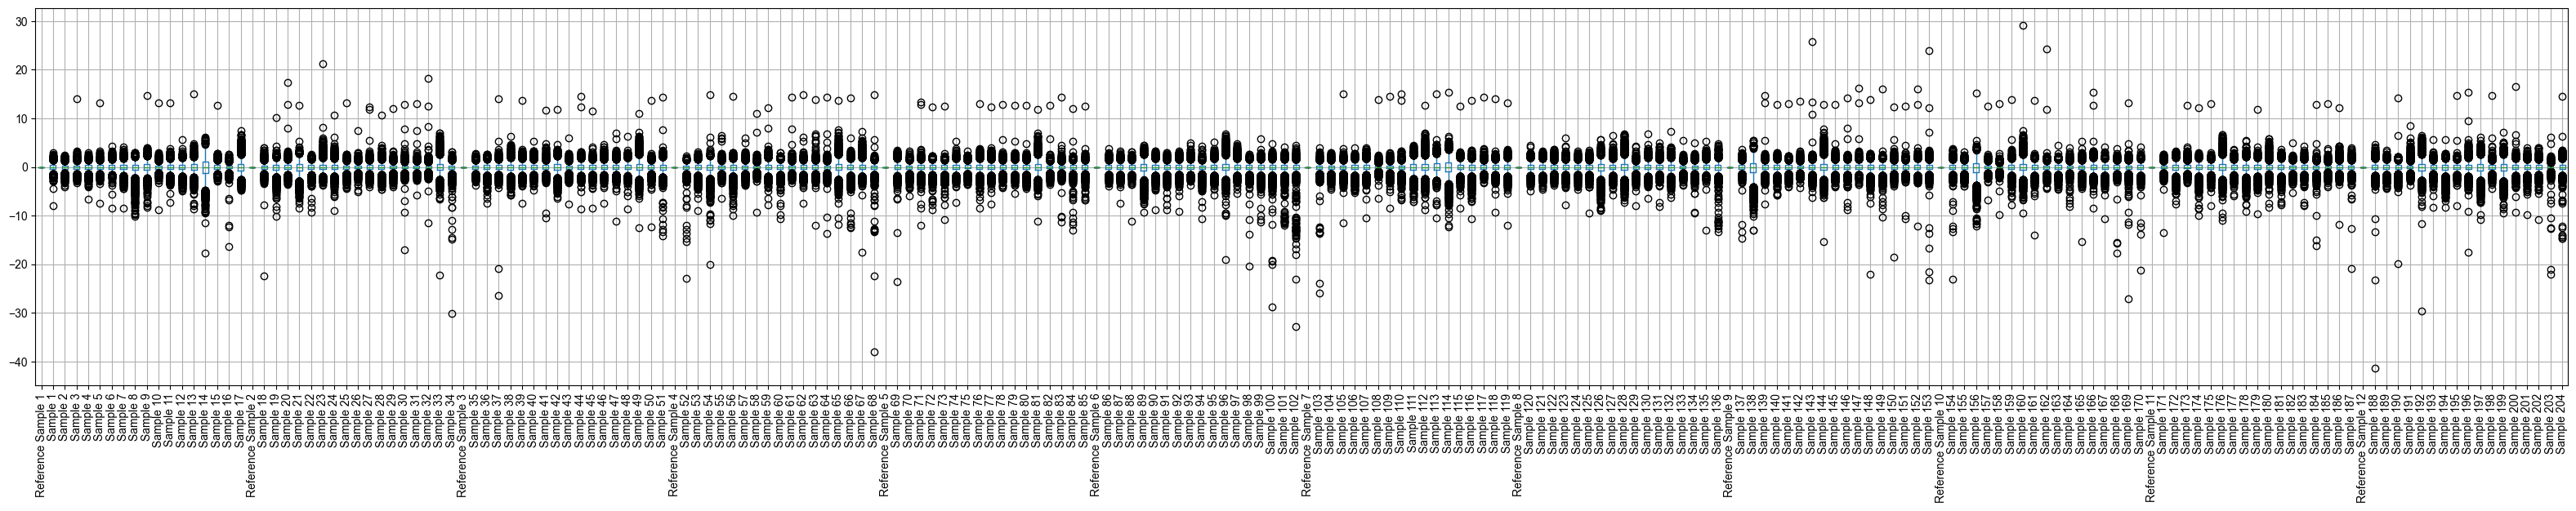

In [23]:
data.boxplot(figsize=(40,6), rot=90)

In [24]:
meta_dir = Path(r"F:\lab\cptac_prostate\data\mspycloud\Sample ID match")
sample_path = meta_dir / "PRAD_TMT_DDA_CPTAC Sample ID match.xlsx"
sample_path.exists()

True

In [25]:
sample_df = pd.read_excel(sample_path)
sample_df

,sample number,sample ID,channel,TMT/DIA set,sample type
0,Referance Sample 1,pool_1,126,1,pool
1,Sample 1,C3L-05292_T,127N,1,tumor
2,Sample 2,C3L-09383_T,127C,1,tumor
3,Sample 3,CHTN-43798_T,128N,1,tumor
4,Sample 4,C3L-06261_N,128C,1,normal
...,...,...,...,...,...
211,Sample 200,C3L-08291_T,133N,12,tumor
212,Sample 201,C3L-10583_T,133C,12,tumor
213,Sample 202,C3L-07877_T,134N,12,tumor
214,Sample 203,C3L-08377_T,134C,12,tumor


In [26]:
sample_map = dict(zip(sample_df["sample number"], sample_df["sample ID"]))

In [27]:
cols = [sample_map.get(i,i) for i in data.columns]
print(len(cols), len(data.columns))

216 216


In [28]:
data.columns = cols
data_nomiss.columns = cols

In [29]:
data

,Reference Sample 1,C3L-05292_T,C3L-09383_T,CHTN-43798_T,C3L-06261_N,C3L-08811_T,C3L-06506_N,C3L-07804_T,C3L-06595_T,C3L-06742_T,...,CHTN-44966_T,C3L-11192_N,C3L-08805_T,C3L-09760_T,C3L-08444_T,C3L-08291_T,C3L-10583_T,C3L-07877_T,C3L-08377_T,C3L-08736_T
Modifications,,,,,,,,,,,,,,,,,,,,,
[304.207146]AAAAAAALQAK[114.042927]SDEK[304.207146],0.0,-0.827655,-0.742708,-0.556025,-0.194037,-0.232627,0.221023,-0.946875,-0.722395,-0.068311,...,0.333053,0.721572,0.821910,0.783937,0.141135,0.019784,-0.056945,0.979122,1.044169,1.730977
[304.207146]AAAASAAEAGIATTGTEDSDDALLK[114.042927]MTISQQEFGR,0.0,-0.090885,-0.051857,-0.075564,-0.750425,-0.249648,0.096765,-0.317282,-2.190656,-1.030893,...,1.727200,2.099415,-0.868990,1.714846,1.321708,1.415628,2.039759,1.665831,1.193453,1.601708
[304.207146]AAAASAAEAGIATTGTEDSDDALLK[114.042927]M[15.99491463]TISQQEFGR,0.0,0.368371,0.406840,-0.311166,0.242944,0.478435,1.223583,-0.068302,-0.763611,0.080631,...,0.361530,0.274437,-0.549142,0.393883,-1.998589,-1.519461,1.042343,-0.141309,-0.100334,-0.247398
[304.207146]AAAEAAAEAK[114.042927]AR,0.0,-0.325326,0.340476,-1.012782,-0.170096,-0.491666,-0.505240,-0.230172,0.438315,-0.085235,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
[304.207146]AAAFEEQENETVVVK[114.042927]EK[304.207146],0.0,-0.771500,-0.092843,0.155859,0.444185,-0.005953,0.062806,0.345561,0.287744,-1.018061,...,-0.160462,1.117618,0.904013,-0.509897,0.540633,-0.747804,0.991785,0.772774,0.323188,-0.413089
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
[304.207146]YQSNSIQIQWFWR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.223130,-0.194829,-0.798569,0.126824,-2.299942,-1.061893,-0.131664,-0.156097,-0.401172,-0.688381
[304.207146]YSTAK[114.042927]NANFYLQAGSAFAEMK[304.207146],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.326152,0.154745,0.062193,1.055814,-1.154543,1.709054,0.866790,-0.148985,0.022976,1.688861
[304.207146]YTIIIPENLK[114.042927]PQMK[304.207146],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.502253,-1.060129,0.026345,-0.126991,-0.694871,-0.047683,-0.028053,-1.380989,-0.169681,-0.051871


In [30]:
from omicsone_streamlit.plots.pca import plot_pca1

In [31]:
print(len(tumors_included), len(normals))

150 33


In [33]:
len(set(data.columns) & set(tumors_included))

150

In [34]:
tumors_included

['C3L-07287_T',
 'C3L-11156_T',
 'C3L-09494_T',
 'CHTN-49141_T',
 'C3L-11095_T',
 'C3L-06504_T',
 'C3L-07473_T',
 'C3L-08293_T',
 'C3L-09382_T',
 'C3L-09691_T',
 'C3L-09757_T',
 'C3L-09801_T',
 'C3L-09990_T',
 'C3N-08476_T',
 'C3N-08532_T',
 'C3N-08879_T',
 'C3N-08880_T',
 'C3N-08949_T',
 'C3N-08878_T',
 'C3L-10486_T',
 'C3L-06183_T',
 'C3L-09383_T',
 'C3L-06743_T',
 'C3L-07871_T',
 'C3L-08290_T',
 'C3L-09797_T',
 'C3L-10005_T',
 'C3N-08477_T',
 'C3L-06662_T',
 'C3L-07877_T',
 'C3L-06901_T',
 'C3L-08444_T',
 'C3L-08942_T',
 'C3L-07875_T',
 'C3L-06656_T',
 'C3L-07606_T',
 'C3L-08286_T',
 'C3L-08288_T',
 'C3L-08330_T',
 'C3L-08941_T',
 'C3L-09107_T',
 'C3L-09759_T',
 'C3L-08243_T',
 'C3N-08535_T',
 'C3L-08933_T',
 'C3L-07804_T',
 'C3L-08814_T',
 'C3L-05670_T',
 'C3L-08811_T',
 'C3L-06595_T',
 'C3L-06969_T',
 'CHTN-40852_T',
 'C3N-08950_T',
 'C3N-08906_T',
 'C3L-09696_T',
 'C3L-10308_T',
 'C3L-06506_T',
 'C3L-09375_T',
 'C3N-08952_T',
 'C3L-08369_T',
 'C3L-08380_T',
 'C3L-08372_T',
 'C3L-

In [35]:
group_map

{'C3L-07287_T': 'Tumor',
 'C3L-11156_T': 'Tumor',
 'C3L-09494_T': 'Tumor',
 'CHTN-49141_T': 'Tumor',
 'C3L-11095_T': 'Tumor',
 'C3L-06504_T': 'Tumor',
 'C3L-07473_T': 'Tumor',
 'C3L-08293_T': 'Tumor',
 'C3L-09382_T': 'Tumor',
 'C3L-09691_T': 'Tumor',
 'C3L-09757_T': 'Tumor',
 'C3L-09801_T': 'Tumor',
 'C3L-09990_T': 'Tumor',
 'C3N-08476_T': 'Tumor',
 'C3N-08532_T': 'Tumor',
 'C3N-08879_T': 'Tumor',
 'C3N-08880_T': 'Tumor',
 'C3N-08949_T': 'Tumor',
 'C3N-08878_T': 'Tumor',
 'C3L-10486_T': 'Tumor',
 'C3L-06183_T': 'Tumor',
 'C3L-09383_T': 'Tumor',
 'C3L-06743_T': 'Tumor',
 'C3L-07871_T': 'Tumor',
 'C3L-08290_T': 'Tumor',
 'C3L-09797_T': 'Tumor',
 'C3L-10005_T': 'Tumor',
 'C3N-08477_T': 'Tumor',
 'C3L-06662_T': 'Tumor',
 'C3L-07877_T': 'Tumor',
 'C3L-06901_T': 'Tumor',
 'C3L-08444_T': 'Tumor',
 'C3L-08942_T': 'Tumor',
 'C3L-07875_T': 'Tumor',
 'C3L-06656_T': 'Tumor',
 'C3L-07606_T': 'Tumor',
 'C3L-08286_T': 'Tumor',
 'C3L-08288_T': 'Tumor',
 'C3L-08330_T': 'Tumor',
 'C3L-08941_T': 'Tumor',

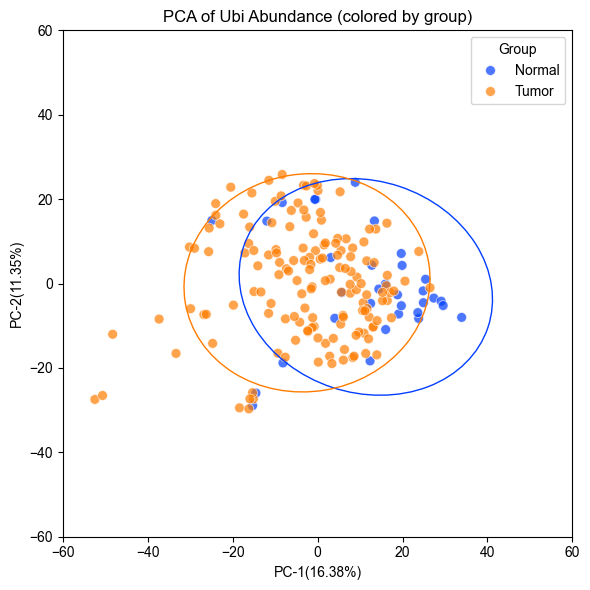

In [45]:
tag = "Ubi"
xlim = (-60,60)
ylim = (-60,60)

group_map = dict()
for i in tumors_included + normals:
    # print(i)
    if i in tumors_included:
        group_map[i] = "Tumor"
    elif i in normals:
        group_map[i] = "Normal"
    else:
        group_map[i] = "Other"
        
data2 = data_nomiss.T.loc[tumors_included + normals,:]
data2['Group'] = data2.index.map(group_map)
data2 = data2.sort_values(by='Group')
    
fig,pca = plot_pca1(data2, n=1, palette='bright', 
                    xlim=xlim, ylim=ylim, figsize=(6,6),
                    title=f"PCA of {tag} Abundance (colored by group)")

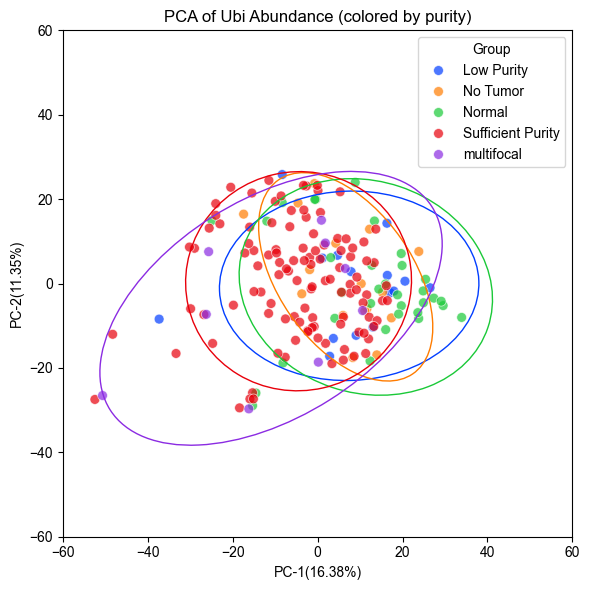

In [46]:
group_map = dict()
for i in tumors_included + normals:
    # print(i)
    if i in tumors_included:
        group_map[i] = purity_map.get(i, "Tumor")
    elif i in normals:
        group_map[i] = "Normal"
    else:
        group_map[i] = "Other"
data2['Group'] = data2.index.map(group_map)
data2 = data2.sort_values(by='Group')
fig,pca = plot_pca1(data2, n=1, palette='bright', 
                    xlim=xlim, ylim=ylim, figsize=(6,6),
                    title=f"PCA of {tag} Abundance (colored by purity)")

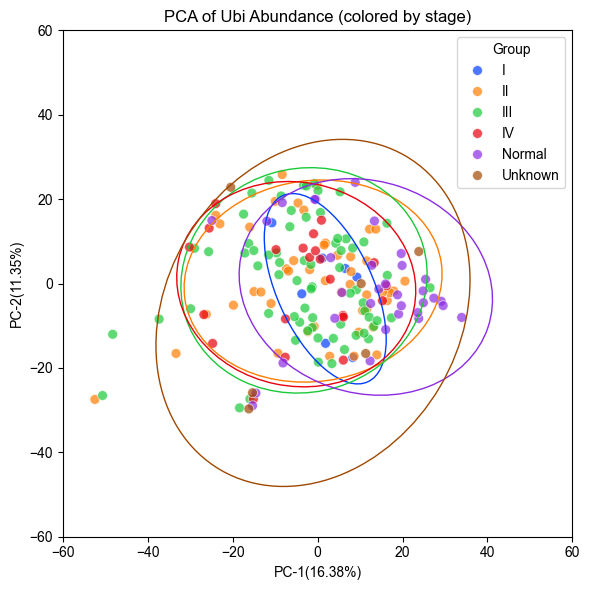

In [47]:
group_map = dict()
for i in tumors_included + normals:
    # print(i)
    if i in tumors_included:
        group_map[i] = re.sub("[ABC]",'',stage_map.get(i, "Tumor"))
    elif i in normals:
        group_map[i] = "Normal"
    else:
        group_map[i] = "Other"
data2['Group'] = data2.index.map(group_map)
data2 = data2.sort_values(by='Group')
fig,pca = plot_pca1(data2, n=1, palette='bright', 
                    xlim=xlim, ylim=xlim, figsize=(6,6),
                    title=f"PCA of {tag} Abundance (colored by stage)")

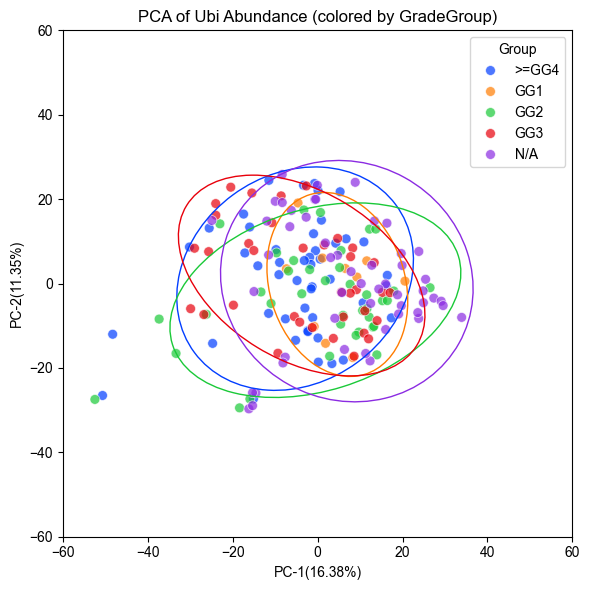

In [48]:
group_map = dict()
for i in tumors_included + normals:
    # print(i)
    if i in tumors_included:
        group_map[i] = str(gleason_map.get(i, "N/A"))
    elif i in normals:
        group_map[i] = "Normal"
    else:
        group_map[i] = "Other"
for i in group_map:
    group_map[i] = 'N/A' if not re.search("GG", group_map[i]) else group_map[i]
data2['Group'] = data2.index.map(group_map)
data2 = data2.sort_values(by='Group')
fig,pca = plot_pca1(data2, n=1, palette='bright', 
                    xlim=xlim, ylim=ylim, figsize=(6,6),
                    title=f"PCA of {tag} Abundance (colored by GradeGroup)")